In [1]:
# TODO- make some maps!  show viz in something other than bar chart!

from shapely.geometry import LineString, Point, Polygon
from shapely import wkt
from geopy.distance import geodesic
import geopandas 
import shapely
import numpy as np
import warnings
import re
warnings.simplefilter(action='ignore', category=FutureWarning)
import pandas as pd
import matplotlib.pyplot as plt
from sklearn import metrics
import seaborn as sns
import plotly.graph_objects as go
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn import metrics
from sklearn.metrics import accuracy_score, confusion_matrix, roc_auc_score
import os
pd.set_option('display.max_columns', None)
pd.set_option('display.max_colwidth', None)
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

/kaggle/input/us-road-construction-and-closures/US_Constructions_Dec21.csv
/kaggle/input/population-of-all-us-cities-2024/Population of all US Cities 2024.csv
/kaggle/input/sf-paths-csv-private/sf_paths.csv


In [3]:
from geopy.distance import geodesic

# Function to calculate distances between each set of consecutive points in linestring
# Need to rename this function.
def calculate_distances_in_linestring(line_string):
    distances = []
    for i in range(len(line_string) - 1):
        point1 = line_string[i]
        point2 = line_string[i + 1]
        distance = geodesic(point1, point2).miles
        distances.append(distance)
        print(f"Distance between {point1} and {point2}: {distance:.3f} miles")
    return distances

# Function to calculate the distance between two points
def calculate_distance_between_points(event1_lat, event1_lng, event_2_lat, event_2_lng):
    point1 = (event1_lat, event1_lng)
    point2 = (event_2_lat, event_2_lng)
    return geodesic(point1, point2).meters

# Function to check temporal overlap or proximity
# Returns True if two times match are under threshold
def check_temporal_proximity(row1, row2, time_threshold=pd.Timedelta('10 minutes')):
    if pd.isna(row1['Start_Time']) or pd.isna(row2['Start_Time']):
        return False
    
    return (abs(row1['Start_Time'] - row2['Start_Time']) <= time_threshold or
            abs(row1['End_Time'] - row2['End_Time']) <= time_threshold or
            (row1['Start_Time'] <= row2['End_Time'] and row1['End_Time'] >= row2['Start_Time']))

In [4]:
event_df= pd.read_csv("/kaggle/input/us-road-construction-and-closures/US_Constructions_Dec21.csv")
route_df = pd.read_csv("/kaggle/input/sf-paths-csv-private/sf_paths.csv")
city_populations = pd.read_csv("/kaggle/input/population-of-all-us-cities-2024/Population of all US Cities 2024.csv")
event_df.head(2)

,ID,Severity,Start_Time,End_Time,Start_Lat,Start_Lng,End_Lat,End_Lng,Distance(mi),Description,Number,Street,Side,City,County,State,Zipcode,Country,Timezone,Airport_Code,Weather_Timestamp,Temperature(F),Wind_Chill(F),Humidity(%),Pressure(in),Visibility(mi),Wind_Direction,Wind_Speed(mph),Precipitation(in),Weather_Condition,Amenity,Bump,Crossing,Give_Way,Junction,No_Exit,Railway,Roundabout,Station,Stop,Traffic_Calming,Traffic_Signal,Turning_Loop,Sunrise_Sunset,Civil_Twilight,Nautical_Twilight,Astronomical_Twilight
0,C-1,4,2019-04-05 16:00:00.000000000,2020-09-29 11:53:57.000000000,32.838360,-93.152378,32.850740,-93.164388,1.103497,Construction on LA-534 WB near EDMONDS LOOP Road closed. Take alternate route.,4200.0,Highway 534,R,Haynesville,Claiborne,LA,71038-7130,US,US/Central,KMNE,2019-04-05 15:55:00,75.0,75.0,58.0,29.72,10.0,S,3.0,0.0,Fair,False,False,False,False,False,False,False,False,False,False,False,False,False,Day,Day,Day,Day
1,C-2,2,2021-11-12 07:59:00.000000000,2021-11-12 08:22:30.000000000,30.221331,-92.008625,30.216642,-92.003809,0.433173,Slow traffic on US-90 E from US-167/Louisiana Ave (US-90) to Surrey St/E University Ave (US-90) due to roadwork.,1098.0,SW Evangeline Trwy,R,Lafayette,Lafayette,LA,70501-8244,US,US/Central,KLFT,2021-11-12 07:59:00,55.0,55.0,100.0,30.09,3.0,CALM,0.0,0.0,Mostly Cloudy,False,False,False,False,False,False,False,False,False,False,False,False,False,Day,Day,Day,Day


In [5]:
event_df.info()
print(event_df['Start_Time'].min(), event_df['Start_Time'].max())
print(len(event_df))
print(event_df['ID'].nunique())
ca_event_df = event_df[event_df['State'] == 'CA']
print(len(ca_event_df))

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 6170627 entries, 0 to 6170626
Data columns (total 47 columns):
 #   Column                 Dtype  
---  ------                 -----  
 0   ID                     object 
 1   Severity               int64  
 2   Start_Time             object 
 3   End_Time               object 
 4   Start_Lat              float64
 5   Start_Lng              float64
 6   End_Lat                float64
 7   End_Lng                float64
 8   Distance(mi)           float64
 9   Description            object 
 10  Number                 float64
 11  Street                 object 
 12  Side                   object 
 13  City                   object 
 14  County                 object 
 15  State                  object 
 16  Zipcode                object 
 17  Country                object 
 18  Timezone               object 
 19  Airport_Code           object 
 20  Weather_Timestamp      object 
 21  Temperature(F)         float64
 22  Wind_Chill(F)     

In [41]:
# Convert Start_Time and End_Time to datetypes.
# Do this before we do any comparisons for duples.
event_df['Start_Time'] = pd.to_datetime(event_df['Start_Time'], errors='coerce')
event_df['End_Time'] = pd.to_datetime(event_df['End_Time'], errors='coerce')
event_df['Weather_Timestamp'] = pd.to_datetime(event_df['Weather_Timestamp'], errors='coerce')
event_df['Coalesced_Timestamp'] = event_df['Start_Time'].fillna(event_df['Weather_Timestamp'])
event_df['Year'] = event_df['Start_Time'].dt.year # Assign Year based on start date
event_df['Coalesced_Year'] = event_df['Coalesced_Timestamp'].dt.year # Assign Year based on start date
event_df['Duration']=round((event_df['End_Time']-event_df['Start_Time'])/np.timedelta64(1,'s'))


In [ ]:
# Can we use Weather_Timestamp when we don't have Start_Time as a proxy to tell us around when the event occurred?  Yes!
temp = event_df.dropna(subset=['Start_Time', 'Weather_Timestamp'])

# Step 2: Calculate the difference between 'Start_Time' and 'Weather_Timestamp'
temp['Time_Difference'] = temp['Start_Time'] - temp['Weather_Timestamp']

# Step 3: Print the differences
temp[['Start_Time', 'Weather_Timestamp', 'Time_Difference']].sort_values(by=['Time_Difference'], ascending=False)

more_than_5_days = temp['Time_Difference'] > pd.Timedelta(days=5)
percentage_more_than_5_days = more_than_5_days.mean() * 100

print(f"% of rows where Time_Difference > 5 days: {percentage_more_than_5_days:.2f}%")

In [8]:
# FINAL DEDUPE CODE
# Dedupe any rows for which we have non-null Start_Lat, Start_Lng, and Start_Time.

null_condition = event_df[['Start_Lat', 'Start_Lng', 'Start_Time']].isnull().any(axis=1)
df_with_nulls = event_df[null_condition]
df_without_nulls = event_df[~null_condition]
df_without_nulls_deduped = df_without_nulls.drop_duplicates(subset=['Start_Lat', 'Start_Lng', 'Start_Time'])
final_df = pd.concat([df_with_nulls, df_without_nulls_deduped]).reset_index(drop=True)

print('len df_with_nulls: ', len(df_with_nulls))
print('len df_without_nulls: ', len(df_without_nulls))
print('len df_without_nulls_deduped: ', len(df_without_nulls_deduped))

print('len final_df: ', len(final_df))


len df_with_nulls:  4360550
len df_without_nulls:  1810077
len df_without_nulls_deduped:  1663969
len final_df:  6024519


In [ ]:
orig_event_df = event_df
event_df = final_df

# Code to reduce size of dataset we need to look at for Bay Area routes.
# Better to use a bounding box but that code took too long to run.
ca_event_df = event_df[event_df['State'] == 'CA']
len(ca_event_df)

In [19]:
# Column coverage
missing = pd.DataFrame(event_df.isna().sum()).reset_index()
missing.columns = ['Feature', 'Missing_Percent(%)']
missing['Missing_Percent(%)'] = missing['Missing_Percent(%)'].apply(lambda x: x / event_df.shape[0] * 100)
missing.loc[missing['Missing_Percent(%)']>0,:].sort_values(by='Missing_Percent(%)', ascending=False)

,Feature,Missing_Percent(%)
2,Start_Time,72
49,Duration,72
48,Year,72
3,End_Time,72
10,Number,44
28,Precipitation(in),15
22,Wind_Chill(F),13
6,End_Lat,10
7,End_Lng,10
27,Wind_Speed(mph),6


In [ ]:
# Only need for path overlap piece
event_df['start_coord'] = list(zip(event_df['Start_Lng'], event_df['Start_Lat']))
event_df['end_coord'] = list(zip(event_df['End_Lng'], event_df['End_Lat']))
#event_df['geometry'] = event_df.apply(lambda row: LineString([row['start_coord'], row['end_coord']]), axis=1)
event_df['geometry'] = event_df.apply(lambda row: Point(row['start_coord']) if pd.isna(row['End_Lat']) or (row['Start_Lat'] == row['End_Lat'] and row['Start_Lng'] == row['End_Lng']) else LineString([row['start_coord'], row['end_coord']]), axis=1)
route_df['geometry'] = route_df['path_wkt'].apply(wkt.loads)
type(route_df['geometry'][0])

In [ ]:
print(len(event_df))

In [ ]:
# 1. Over the past 5 years which city has had the most hours of construction?
grouped_df = event_df.groupby('City')['Duration'].sum()/3600

# Sort the result by the summed 'Duration' in descending order
sorted_df = grouped_df.sort_values(ascending=False)
pd.set_option('display.float_format', '{:.0f}'.format)

print(sorted_df)

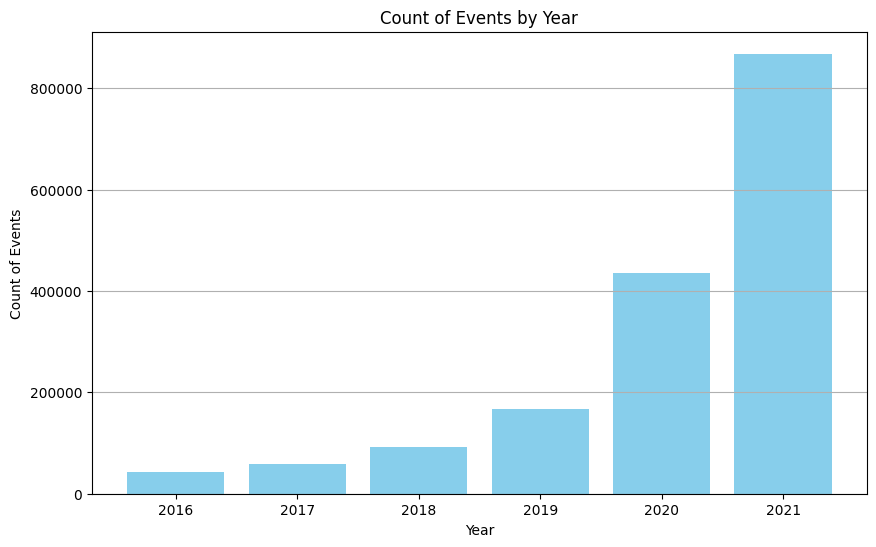

In [12]:
# If we assign Year based on coalesce(Start_Time, Weather_Timestamp), do we see a more even distribution of event counts?  No.
# Let's look at only those events with Start_Time by year.
yearly_counts = event_df.groupby('Year').size().reset_index(name='count')

# Sort by Year in ascending order
yearly_counts = yearly_counts.sort_values('Year')

# Plot the data
plt.figure(figsize=(10, 6))
plt.bar(yearly_counts['Year'], yearly_counts['count'], color='skyblue')
plt.xlabel('Year')
plt.ylabel('Count of Events')
plt.title('Count of Events by Year')
plt.xticks(yearly_counts['Year'])  # Ensure all years are shown on the x-axis
plt.grid(axis='y')
plt.show()

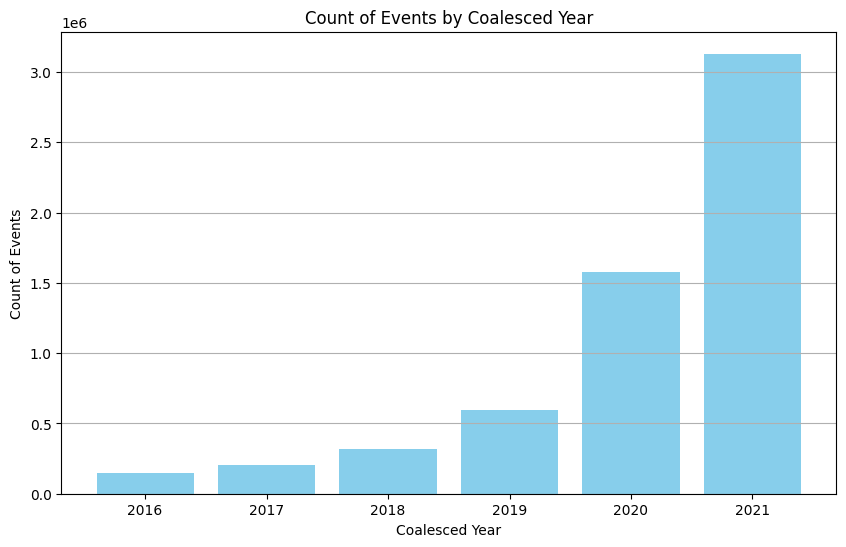

In [15]:
# If we assign Year based on coalesce(Start_Time, Weather_Timestamp), do we see a more even distribution of event counts?  No.
# It's just many more events, but the distribution of all the events across years seems similar.
yearly_counts = event_df.groupby('Coalesced_Year').size().reset_index(name='count')

# Sort by Year in ascending order
yearly_counts = yearly_counts.sort_values('Coalesced_Year')

# Plot the data
plt.figure(figsize=(10, 6))
plt.bar(yearly_counts['Coalesced_Year'], yearly_counts['count'], color='skyblue')
plt.xlabel('Coalesced Year')
plt.ylabel('Count of Events')
plt.title('Count of Events by Coalesced Year')
plt.xticks(yearly_counts['Coalesced_Year'])  # Ensure all years are shown on the x-axis
plt.grid(axis='y')
plt.show()

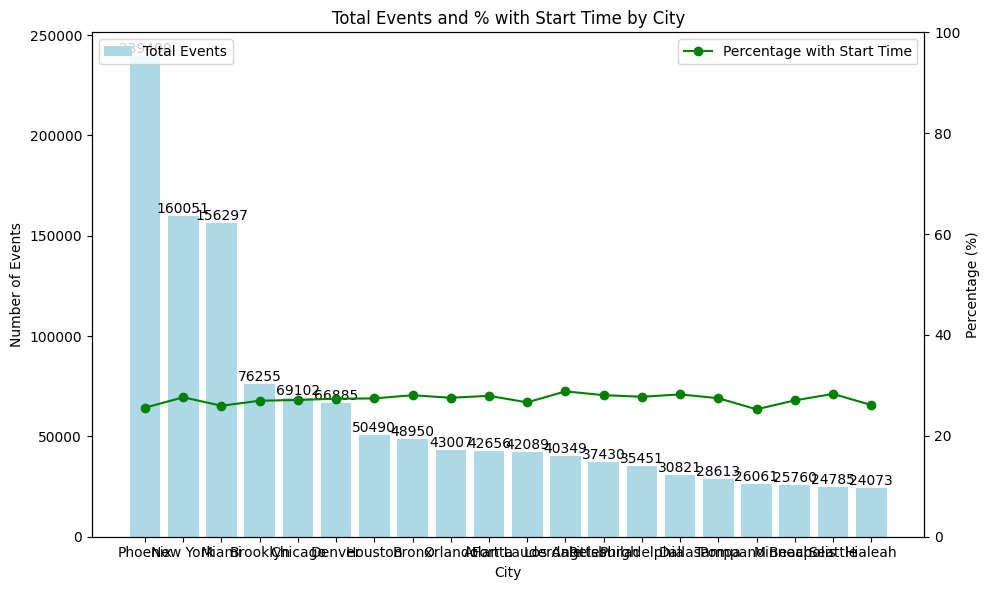

In [18]:
# Understand start_time coverage for various cities.
# Let's look at them in city event volume descending order.

# Count the total number of events per city
total_events_per_city = event_df.groupby('City').size()

# Count the number of events with a Start_time per city
events_with_start_time = event_df[event_df['Start_Time'].notna()].groupby('City').size()

# Calculate the percentage of events with Start_time
percentage_with_start_time = (events_with_start_time / total_events_per_city) * 100

# Combine the data into a DataFrame and sort by percentage in descending order
result = pd.DataFrame({
    'Total Events': total_events_per_city,
    'Events with Start Time': events_with_start_time,
    'Percentage with Start Time': percentage_with_start_time
})

# Sort the result by percentage in descending order
#result = result.sort_values(by='Percentage with Start Time', ascending=False)
result = result.sort_values(by='Total Events', ascending=False).head(20)


# Plotting the bar chart
fig, ax = plt.subplots(figsize=(10, 6))

# Bar plot for total events
bars = ax.bar(result.index, result['Total Events'], color='lightblue', label='Total Events')

# Add text labels to the bars (the percentage of events with Start Time)
for bar in bars:
    yval = bar.get_height()
    ax.text(bar.get_x() + bar.get_width()/2, yval + 0.1, f'{yval}', ha='center', va='bottom')

# Set labels and title
ax.set_xlabel('City')
ax.set_ylabel('Number of Events')
ax.set_title('Total Events and % with Start Time by City')

# Add a secondary y-axis for percentage
ax2 = ax.twinx()
ax2.plot(result.index, result['Percentage with Start Time'], color='green', marker='o', label='Percentage with Start Time')
ax2.set_ylabel('Percentage (%)')

# Display legend
ax.legend(loc='upper left')
ax2.legend(loc='upper right')
ax2.set_ylim(0, 100)
# Show the plot
plt.xticks(rotation=45, ha='right', rotation_mode='anchor')
plt.tight_layout()
plt.show()

/tmp/ipykernel_30/1130157445.py:14: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  top_cities_per_year = grouped_df.groupby('Year').apply(lambda x: x.nlargest(5, 'Duration')).reset_index(drop=True)


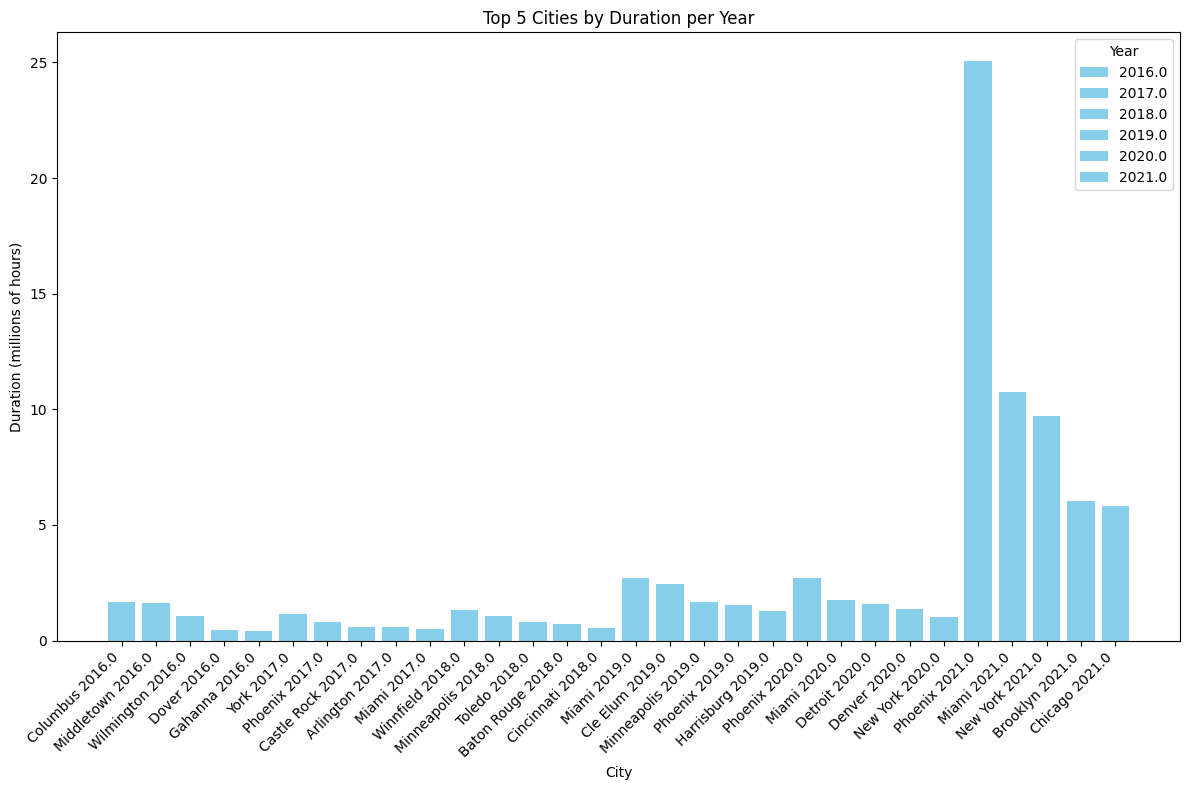

,City,Year,Duration
0,Columbus,2016,2
1,Middletown,2016,2
2,Wilmington,2016,1
3,Dover,2016,0
4,Gahanna,2016,0
5,York,2017,1
6,Phoenix,2017,1
7,Castle Rock,2017,1
8,Arlington,2017,1
9,Miami,2017,1


In [29]:
# 2. How has the top city in # of construction hours changed over time?
# It's not clear if we just started emitting/collecting events more thoroughly in recent years
# or if in fact, construction events have suddenly skyrocketed in recent years (unlikely).

# Couldn't get color coding to work here.

import pandas as pd
import matplotlib.pyplot as plt

# Group by 'City' and 'Year' and sum the 'Duration' values
grouped_df = event_df.groupby(['City', 'Year'])['Duration'].sum().reset_index()

# Convert Duration from seconds to hours - and for readability, make it into millions
grouped_df['Duration'] = grouped_df['Duration'] / 3600 / 1000000

# For each year, select the top 5 cities based on the summed 'Duration'
top_cities_per_year = grouped_df.groupby('Year').apply(lambda x: x.nlargest(5, 'Duration')).reset_index(drop=True)

# Sort by year ascending and within each year by Duration descending
top_cities_per_year_sorted = top_cities_per_year.sort_values(by=['Year', 'Duration'], ascending=[True, False])

# Plot the bar chart
plt.figure(figsize=(12, 8))


for year in sorted(top_cities_per_year_sorted['Year'].unique()):
    yearly_data = top_cities_per_year_sorted[top_cities_per_year_sorted['Year'] == year]
    plt.bar(yearly_data['City'] + ' ' + yearly_data['Year'].astype(str), yearly_data['Duration'], label=str(year), color='skyblue')

plt.xlabel('City')
plt.ylabel('Duration (millions of hours)')
plt.title('Top 5 Cities by Duration per Year')
plt.xticks(rotation=45, ha='right')
plt.legend(title='Year')
plt.tight_layout()

plt.show()
top_cities_per_year_sorted

In [53]:

# 3. If we account for varying city sizes (pick your metric) how do the 10 largest cities in the US compare?
city_list = ['New York', 'Los Angeles', 'Chicago', 'Houston', 'Phoenix', 'San Antonio', 'Philadelphia', 'San Diego', 'Dallas', 'Austin']
ten_city_event_df = event_df[event_df["City"].isin(city_list)]

severity_counts = ten_city_event_df.groupby(['City', 'Severity']).size().unstack(fill_value=0)
severity_counts = severity_counts.reset_index()
city_scores = pd.merge(severity_counts, city_populations[['US City', 'Population 2024']], how='left', left_on='City', right_on='US City')
city_scores = city_scores.drop(columns=['US City'])


city_scores.columns = ['city', 'num_sev1_events', 'num_sev2_events', 'num_sev3_events', 'num_sev4_events', 'population']
city_scores['agg_score'] = (city_scores['num_sev1_events']+city_scores['num_sev2_events']*2+city_scores['num_sev3_events']*4+city_scores['num_sev4_events']*8)/city_scores['population']*10000
city_scores['num_sev1_events_pp'] = city_scores['num_sev1_events']/city_scores['population']*10000
city_scores['num_sev2_events_pp'] = city_scores['num_sev2_events']/city_scores['population']*10000
city_scores['num_sev3_events_pp'] = city_scores['num_sev3_events']/city_scores['population']*10000
city_scores['num_sev4_events_pp'] = city_scores['num_sev4_events']/city_scores['population']*10000
city_scores['total_num_events_pp'] = city_scores['num_sev1_events_pp'] + city_scores['num_sev2_events_pp'] + city_scores['num_sev3_events_pp'] + city_scores['num_sev4_events_pp']

city_scores['agg_score_normalized'] = (city_scores['agg_score'] - city_scores['agg_score'].min()) / (city_scores['agg_score'].max() - city_scores['agg_score'].min()) * 100
city_scores.to_csv('city_scores.csv', index=False) 
city_scores

,city,num_sev1_events,num_sev2_events,num_sev3_events,num_sev4_events,population,agg_score,num_sev1_events_pp,num_sev2_events_pp,num_sev3_events_pp,num_sev4_events_pp,total_num_events_pp,agg_score_normalized
0,Austin,111,7756,1412,2007,984567,379,1,79,14,20,115,0
1,Chicago,278,57382,4409,7033,2638159,716,1,218,17,27,262,13
2,Dallas,104,23726,3351,3640,1302753,691,1,182,26,28,237,12
3,Houston,119,35570,2798,12003,2319119,770,1,153,12,52,218,15
4,Los Angeles,833,22333,6089,11094,3795936,418,2,59,16,29,106,1
5,New York,907,147350,2652,9142,8097282,468,1,182,3,11,198,3
6,Philadelphia,915,23086,3106,8344,1533828,823,6,151,20,54,231,17
7,Phoenix,255,233228,1183,4734,1662607,3063,2,1403,7,28,1440,100
8,San Antonio,103,10035,1769,4175,1513974,401,1,66,12,28,106,1
9,San Diego,58,7101,4517,3501,1388996,434,0,51,33,25,109,2


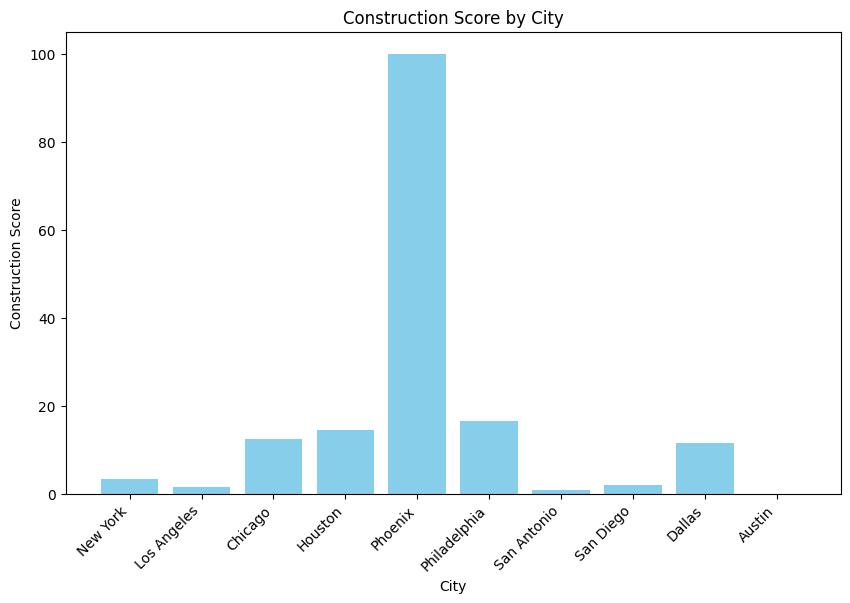

KeyError: "['color'] not in index"

In [58]:
# Compare top 10 cities
city_scores = city_scores.sort_values(by='population', ascending=False)

# Couldn't get this to work!
#cities = city_scores['city'].unique()
#colors = plt.cm.viridis(range(len(cities)))
#color_map = {city: colors[i] for i, city in enumerate(cities)}
#city_scores['color'] = city_scores['city'].map(color_map)

# Plotting the bar chart
plt.figure(figsize=(10, 6))  # Set the figure size
plt.bar(city_scores['city'], city_scores['agg_score_normalized'], color='skyblue')

# Adding labels and title
plt.xlabel('City')
plt.ylabel('Construction Score')
plt.title('Construction Score by City')
plt.xticks(rotation=45, ha='right')

# Display the plot
plt.show()
city_scores[['city', 'color']]

In [ ]:
city_scores = city_scores.sort_values(by='population', ascending=False)

# Plotting the bar chart
plt.figure(figsize=(10, 6))  # Set the figure size
plt.bar(city_scores['city'], city_scores['total_num_events_pp'], color='skyblue')

# Adding labels and title
plt.xlabel('City')
plt.ylabel('# Events Per 10k People')
plt.title('# Events Per 10k People by City')
plt.xticks(rotation=45, ha='right')

# Display the plot
plt.show()


In [ ]:
city_scores = city_scores.sort_values(by='population', ascending=False)

# Plotting the bar chart
plt.figure(figsize=(10, 6))  # Set the figure size
plt.bar(city_scores['city'], city_scores['agg_score_normalized'], color='skyblue')

# Adding labels and title
plt.xlabel('City')
plt.ylabel('City Score')
plt.title('City Construction Scores')
plt.xticks(rotation=45, ha='right')

# Display the plot
plt.show()

In [ ]:
# TEST CODE TO FIGURE OUT DATA TYPE CONVERSIONS
#print(route_df['path_wkt'][0])
# (-122.41928, 37.77492) - longitude, latitude in wkt and shapely format (apparently other libs do it in reverse order)

line_string_wkt = route_df['path_wkt'][0]
line_string = shapely.wkt.loads(line_string_wkt)
coords = list(line_string.coords)
#print(coords)
coords_reversed = [(lat, lon) for lon, lat in line_string.coords]
distances = calculate_distances(coords_reversed)


In [ ]:
def calculate_overlap(route, event_df):
    total_overlap = 0
    for _, event in event_df.iterrows():
        event_line = event['geometry']
        if route.intersects(event_line):
            overlap = route.intersection(event_line)
            total_overlap += overlap.length
    return total_overlap

def calculate_overlap_w_buffer(route, event_df):
    buffer_distance = 0.00005  # 18 feetish in degrees
    route_buffer = route.buffer(buffer_distance)
    
    total_overlap = 0
    for _, event in event_df.iterrows():
        event_line = event['geometry']
        if route_buffer.intersects(event_line):
            overlap = route_buffer.intersection(event_line)
            total_overlap += overlap.length
    return total_overlap
    
def fix_invalid_geometry(geometry):
    if not geometry.is_valid:
        print(f"Invalid geometry found: {geometry}")
        return geometry.buffer(0)  # Fix the geometry by buffering by 0
    return geometry

# Fix invalid geometries in the DataFrames
route_df['geometry'] = route_df['geometry'].apply(fix_invalid_geometry)
event_df['geometry'] = event_df['geometry'].apply(fix_invalid_geometry)

# Apply the overlap calculation to each route
route_df['overlap_length'] = route_df['geometry'].apply(calculate_overlap_w_buffer, event_df=ca_event_df)

# Print the result
print(route_df[['path_name', 'overlap_length']])


In [ ]:
# TRY 1 for dupes - This takes forever to run.  Won't use.
# Are there similar/same events reported by multiple sources that are in fact duplicates?
# Let's define a duplicate event as one that has a timestamp within 10 minutes of another 
# and one that has a start lat/long within 5 meters of another.

# Test with subset so we don't time out.
mini_event_df = event_df[event_df["City"] == 'Berkeley'].reset_index()
print("num entries: ", len(mini_event_df))

# Define a distance threshold (e.g., 100 meters)
distance_threshold = 5

# Iterate over pairs of rows to find similar events
similar_events = []

for i, row1 in mini_event_df.iterrows():
    for j, row2 in mini_event_df.iterrows():
        if i < j:  # Avoid comparing the same pair twice and skip self-comparison
            distance = calculate_distance_between_points(row1['Start_Lat'], row1['Start_Lng'], row2['Start_Lat'], row2['Start_Lng']):
            if distance <= distance_threshold:
                if check_temporal_proximity(row1, row2):
                    similar_events.append((row1['ID'], row2['ID']))

print("Similar Events (based on spatial and temporal proximity):")
print(similar_events)

In [ ]:
# TRY 2 for dupes - Takes a long time to run.  No time to test and validate. Won't use.
# This is probably a better method to find dupes than strict exact matches.

mini_event_df = event_df[event_df["City"] == 'Berkeley']

degree_tolerance = 0.00001 # if 1 degree = 69 miles, then .00001 degree ~ 3.7 feet
time_threshold=pd.Timedelta('10 minutes')

def is_duplicate(row, df, degree_tolerance, time_threshold):
    start_lat_cond = np.abs(df['Start_Lat'] - row['Start_Lat']) <= degree_tolerance
    start_lng_cond = np.abs(df['Start_Lng'] - row['Start_Lng']) <= degree_tolerance
    end_lat_cond = np.abs(df['End_Lat'] - row['End_Lat']) <= degree_tolerance
    end_lng_cond = np.abs(df['End_Lng'] - row['End_Lng']) <= degree_tolerance
    start_time_cond = np.abs(df['Start_Time'] - row['Start_Time']) <= time_threshold
    end_time_cond = np.abs(df['End_Time'] - row['End_Time']) <= time_threshold
    return start_lat_cond & start_lng_cond & end_lat_cond & end_lng_cond & (start_time_cond | end_time_cond)

# Create a boolean series to mark duplicates
duplicates = pd.Series([is_duplicate(row, event_df, degree_tolerance, time_threshold).sum() > 1 for index, row in event_df.iterrows()])

event_df['duplicate'] = duplicates
print(f"Number of duplicate rows: {len(duplicates[duplicates == True])}")

# Keep only the first occurrence of each duplicate group
def filter_duplicates(df, degree_tolerance, time_threshold):
    keep_indices = []
    seen = pd.Series([False] * len(df))

    for index, row in df.iterrows():
        if not seen[index]:
            duplicate_indices = is_duplicate(row, df, degree_tolerance, time_threshold)
            seen[duplicate_indices] = True
            keep_indices.append(index)
    
    return df.loc[keep_indices]

unique_events_df = filter_duplicates(mini_event_df, degree_tolerance, time_threshold)
unique_events_df = unique_events_df.drop(columns=['duplicate'])

# Display the results
print(f"Number of unique rows after removing duplicates: {len(unique_events_df)}")